# Proyecto 3 — PCA y Visualización Comparativa de Clustering

## Integrantes
- Daniel Fernando Salgado Santamaria
- Jairo Wladimir Jhayya Perlaza
- Luis Gabriel Salgado Santamaria
- Oscar Paul Naranjo Castro

**Fecha:** 2026-05-14  
**Notebook:** `05-jj-pca-clientes.ipynb`

## Objetivo

Aplicar **PCA (Análisis de Componentes Principales)** como técnica de reducción lineal de dimensionalidad sobre los datos de clientes, visualizar los clusters generados por K-Means y DBSCAN en el espacio reducido de 2 componentes principales, y comparar la efectividad de PCA vs t-SNE para revelar la estructura de agrupamiento. Se analizará la varianza explicada por cada componente y se interpretarán los *loadings* de las variables originales.

## Configuración del entorno

Se importan todas las librerías necesarias para PCA, clustering, visualización y análisis estadístico.

In [1]:
# Importa librerías estándar de manejo de rutas y sistema.
import sys
from pathlib import Path

# Importa librerías numéricas y de análisis de datos.
import numpy as np
import pandas as pd

# Importa herramientas de visualización de alta calidad.
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Importa modelos y métricas de scikit-learn para clustering y reducción.
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

# Verifica que el notebook esté usando el entorno virtual correcto.
print("Python ejecutándose desde:")
print(sys.executable)

Python ejecutándose desde:
g:\ProyectosPython\proyecto3\.venv\Scripts\python.exe


## Configuración visual global

Se establece el estilo, resolución y tamaño de fuente para todos los gráficos del notebook,
asegurando uniformidad visual y calidad de exportación a 400 DPI.

In [2]:
# Configura el estilo visual global: grilla limpia, contexto talk para fuentes legibles.
sns.set_theme(style="whitegrid", context="talk")

# Establece resolución de pantalla y de guardado para gráficos de alta calidad.
plt.rcParams["figure.dpi"]      = 140
plt.rcParams["savefig.dpi"]     = 400
plt.rcParams["axes.titlesize"]  = 16
plt.rcParams["axes.labelsize"]  = 13
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11
plt.rcParams["legend.fontsize"] = 11
plt.rcParams["font.weight"]          = "regular"
plt.rcParams["axes.titleweight"]     = "bold"
plt.rcParams["axes.labelweight"]     = "bold"

# Define la paleta de colores vivos y profesionales usada en todo el proyecto.
PALETTE_VIVID = [
    "#0F766E",  # teal intenso
    "#2563EB",  # azul vivo
    "#DC2626",  # rojo elegante
    "#F59E0B",  # ámbar
    "#7C3AED",  # violeta controlado
    "#059669",  # verde fuerte
    "#EA580C",  # naranja profundo
    "#DB2777",  # magenta elegante
    "#0891B2",  # cyan fuerte
    "#65A30D",  # lima oscura
]

print("Configuración visual aplicada correctamente.")

Configuración visual aplicada correctamente.


## Definición de rutas del proyecto

Se definen rutas absolutas de forma reproducible para que el notebook funcione
correctamente desde cualquier máquina del equipo sin necesidad de modificar paths manualmente.

In [3]:
# Define la raíz del proyecto de forma dinámica según desde dónde se ejecute el notebook.
PROJECT_ROOT = (
    Path.cwd().resolve().parent
    if Path.cwd().name == "notebooks"
    else Path.cwd().resolve()
)

# Define rutas de datos procesados y carpetas de figuras y tablas.
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_PCA   = PROJECT_ROOT / "reports" / "figures" / "pca"
FIGURES_CMP   = PROJECT_ROOT / "reports" / "figures" / "clustering_clientes"
TABLES_DIR    = PROJECT_ROOT / "reports" / "tables"

# Crea las carpetas de destino si no existen.
for path in [FIGURES_PCA, FIGURES_CMP, TABLES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT :", PROJECT_ROOT)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("FIGURES_PCA  :", FIGURES_PCA)
print("FIGURES_CMP  :", FIGURES_CMP)

PROJECT_ROOT : G:\ProyectosPython\proyecto3\desarrollo3
PROCESSED_DIR: G:\ProyectosPython\proyecto3\desarrollo3\data\processed
FIGURES_PCA  : G:\ProyectosPython\proyecto3\desarrollo3\reports\figures\pca
FIGURES_CMP  : G:\ProyectosPython\proyecto3\desarrollo3\reports\figures\clustering_clientes


## Funciones auxiliares

Se definen funciones reutilizables para guardar figuras y anotar barras con valores,
garantizando uniformidad visual en todos los gráficos del notebook.

In [4]:
# Define función para guardar la figura activa en alta resolución en la carpeta indicada.
def f_save_plot(filename, folder):
    """Guarda la figura activa en la carpeta especificada a 400 DPI."""
    plt.savefig(folder / filename, dpi=400, bbox_inches="tight", facecolor="white")


# Define función para anotar barras verticales con su valor encima de cada barra.
def f_annotate_bars(ax, fmt="{:.0f}", suffix="", fontsize=10, weight="bold"):
    """Añade etiquetas sobre cada barra vertical del gráfico."""
    for patch in ax.patches:
        height = patch.get_height()
        if pd.notnull(height):
            x = patch.get_x() + patch.get_width() / 2
            ax.annotate(
                fmt.format(height) + suffix,
                (x, height),
                ha="center", va="bottom",
                fontsize=fontsize, fontweight=weight,
                xytext=(0, 6), textcoords="offset points",
            )


print("Funciones auxiliares definidas correctamente.")

Funciones auxiliares definidas correctamente.


## 1. Carga y verificación de datos

Se carga el archivo `customer_features.csv` generado en el notebook 02 EDA, que contiene
las métricas consolidadas por cliente. Este archivo es la base para todos los modelos de este notebook.

In [5]:
# Carga el archivo de características de clientes generado en el notebook de EDA.
customer_features = pd.read_csv(PROCESSED_DIR / "customer_features.csv")

# Muestra las dimensiones y primeras filas para verificar integridad del archivo.
print("Dimensiones:", customer_features.shape)
customer_features.head()

Dimensiones: (20000, 10)


,customer_id,country,age,signup_date,marketing_opt_in,n_sessions,n_orders,gross_revenue_usd,avg_order_value_usd,n_reviews
0,1,JP,71,2020-09-04,True,5.0,2.0,115.39,57.695,1.0
1,2,IN,26,2020-04-05,False,3.0,2.0,68.52,34.260,0.0
2,3,BR,21,2023-08-31,True,5.0,1.0,66.72,66.720,0.0
3,4,FR,63,2022-06-30,True,9.0,2.0,279.86,139.930,0.0
4,5,BR,19,2022-07-22,True,9.0,3.0,271.29,90.430,4.0


## 2. Preprocesamiento para PCA

PCA es sensible a la escala de las variables. Se seleccionan únicamente las variables
numéricas de comportamiento y se aplica `StandardScaler` para normalizar cada variable
a media 0 y desviación estándar 1, eliminando el efecto de magnitud.

In [6]:
# Define las variables numéricas de comportamiento para el análisis.
# Se excluyen identificadores (customer_id) y fechas (signup_date).
FEATURE_COLS = [
    "age", "n_sessions", "n_orders",
    "gross_revenue_usd", "avg_order_value_usd", "n_reviews",
]

# Filtra solo las columnas disponibles en el dataset para evitar errores.
FEATURE_COLS = [c for c in FEATURE_COLS if c in customer_features.columns]
print("Variables utilizadas:", FEATURE_COLS)

# Extrae la matriz de características y escala a media=0, std=1.
X = customer_features[FEATURE_COLS].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Matriz escalada: {X_scaled.shape[0]} clientes × {X_scaled.shape[1]} variables")

Variables utilizadas: ['age', 'n_sessions', 'n_orders', 'gross_revenue_usd', 'avg_order_value_usd', 'n_reviews']
Matriz escalada: 20000 clientes × 6 variables


## 3. Aplicación de PCA

**PCA (Principal Component Analysis)** transforma las variables originales en componentes
ortogonales ordenados por varianza capturada. Se aplica con **2 componentes** para
visualización 2D y se calculan varianza individual y acumulada.

In [7]:
# Aplica PCA con 2 componentes principales para reducción a 2D.
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Almacena las coordenadas PCA en el DataFrame para graficar con etiquetas de cluster.
customer_features["pca_1"] = X_pca[:, 0]
customer_features["pca_2"] = X_pca[:, 1]

# Calcula varianza explicada por cada componente y acumulada.
var_exp = pca.explained_variance_ratio_
var_cum = var_exp.cumsum()

print("PCA completado. Forma del resultado:", X_pca.shape)
print(f"Varianza explicada PC1:              {var_exp[0]:.2%}")
print(f"Varianza explicada PC2:              {var_exp[1]:.2%}")
print(f"Varianza acumulada (PC1 + PC2):      {var_cum[1]:.2%}")

PCA completado. Forma del resultado: (20000, 2)
Varianza explicada PC1:              43.22%
Varianza explicada PC2:              17.53%
Varianza acumulada (PC1 + PC2):      60.76%


## 4. Gráfico de varianza explicada (Scree Plot)

El **Scree Plot** muestra la proporción de varianza que captura cada componente principal.
Ayuda a decidir cuántos componentes retener: se busca el "codo" donde la varianza
marginal de los componentes adicionales se vuelve pequeña.

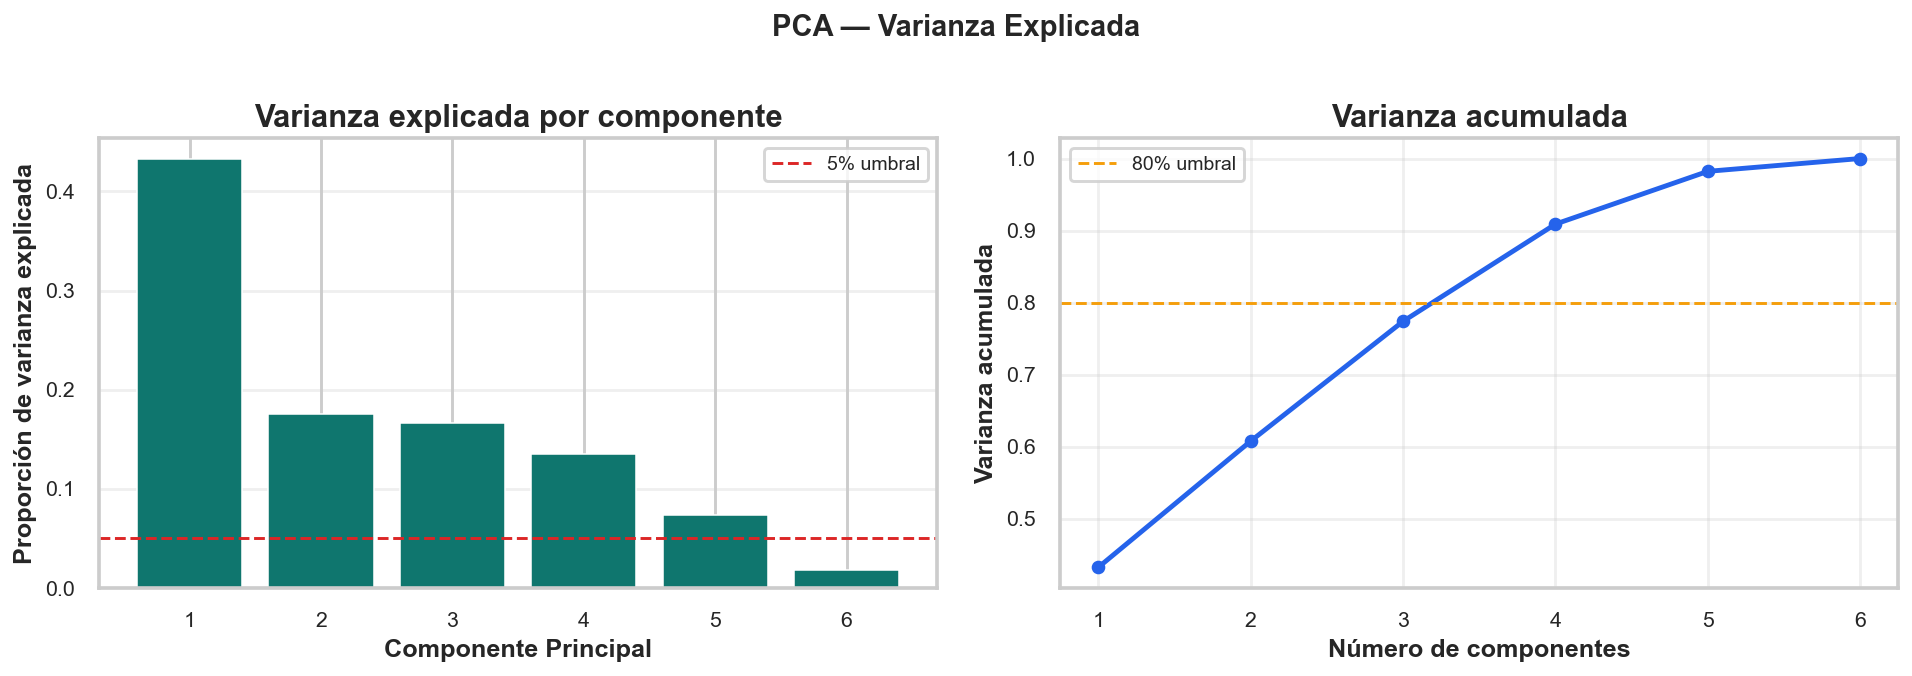

Gráfico guardado: pca_scree_plot.png


In [8]:
# Calcula PCA completo (todos los componentes) para el scree plot.
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)
var_exp_full = pca_full.explained_variance_ratio_
var_cum_full = var_exp_full.cumsum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: varianza explicada por cada componente (barras).
ax0 = axes[0]
ax0.bar(
    range(1, len(var_exp_full) + 1), var_exp_full,
    color=PALETTE_VIVID[0], edgecolor="white", linewidth=0.8
)
ax0.axhline(y=0.05, color=PALETTE_VIVID[2], linestyle="--", linewidth=1.5, label="5% umbral")
ax0.set_title("Varianza explicada por componente", fontweight="bold")
ax0.set_xlabel("Componente Principal")
ax0.set_ylabel("Proporción de varianza explicada")
ax0.legend(fontsize=10)
ax0.grid(axis="y", alpha=0.3)

# Subplot 2: varianza acumulada (línea).
ax1 = axes[1]
ax1.plot(
    range(1, len(var_cum_full) + 1), var_cum_full,
    marker="o", color=PALETTE_VIVID[1], linewidth=2.5, markersize=6
)
ax1.axhline(y=0.80, color=PALETTE_VIVID[3], linestyle="--", linewidth=1.5, label="80% umbral")
ax1.set_title("Varianza acumulada", fontweight="bold")
ax1.set_xlabel("Número de componentes")
ax1.set_ylabel("Varianza acumulada")
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

plt.suptitle("PCA — Varianza Explicada", fontsize=15, fontweight="bold")
plt.tight_layout()
f_save_plot("pca_scree_plot.png", FIGURES_PCA)
plt.show()
print("Gráfico guardado: pca_scree_plot.png")

## 5. Recuperación de clusters previos (K-Means y DBSCAN)

Se recuperan las etiquetas de cluster de los notebooks 03 y 04. Si no existen en
`customer_features`, se re-entrenan con los mismos hiperparámetros óptimos.

In [9]:
# Verifica si ya existen las columnas de cluster; si no, las re-entrena.
if "cluster_kmeans" not in customer_features.columns:
    print("Entrenando K-Means con k=2 (óptimo del notebook 03)...")
    kmeans = KMeans(n_clusters=2, random_state=42, n_init=20)
    customer_features["cluster_kmeans"] = kmeans.fit_predict(X_scaled)
else:
    print("Columna 'cluster_kmeans' ya existe.")

if "cluster_dbscan" not in customer_features.columns:
    print("Entrenando DBSCAN con eps=1.11, min_samples=5 (óptimo del notebook 04)...")
    dbscan = DBSCAN(eps=1.11, min_samples=5)
    customer_features["cluster_dbscan"] = dbscan.fit_predict(X_scaled)
else:
    print("Columna 'cluster_dbscan' ya existe.")

print("\nDistribución K-Means:", customer_features["cluster_kmeans"].value_counts().sort_index().to_dict())
print("Distribución DBSCAN: ", customer_features["cluster_dbscan"].value_counts().sort_index().to_dict())

Entrenando K-Means con k=2 (óptimo del notebook 03)...
Entrenando DBSCAN con eps=1.11, min_samples=5 (óptimo del notebook 04)...

Distribución K-Means: {0: 7041, 1: 12959}
Distribución DBSCAN:  {-1: 266, 0: 19710, 1: 9, 2: 5, 3: 5, 4: 5}


## 6. PCA coloreado por clusters K-Means

Se proyectan los clientes en PC1 vs PC2 y se colorean según K-Means.
Permite evaluar si la separación lineal de PCA coincide con los clusters encontrados.

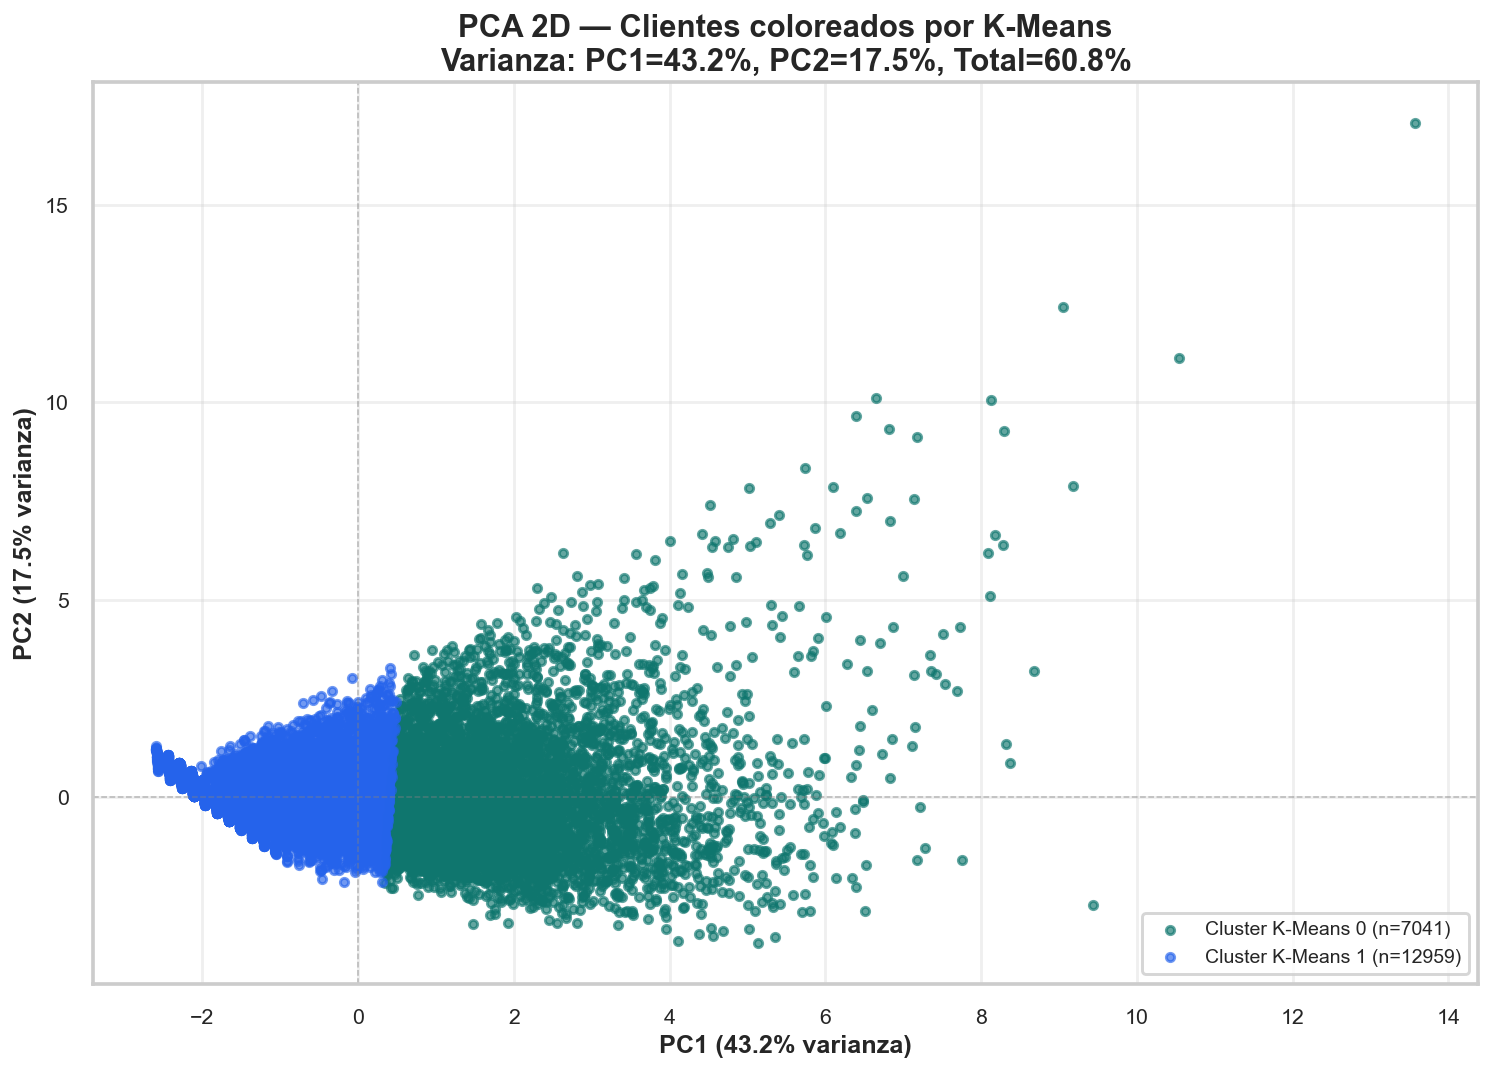

Gráfico guardado: pca_clusters_kmeans.png


In [10]:
# PCA 2D coloreado por cluster K-Means.
plt.figure(figsize=(11, 8))

for idx, cluster_id in enumerate(sorted(customer_features["cluster_kmeans"].unique())):
    subset = customer_features[customer_features["cluster_kmeans"] == cluster_id]
    plt.scatter(
        subset["pca_1"], subset["pca_2"],
        c=PALETTE_VIVID[idx % len(PALETTE_VIVID)],
        alpha=0.65, s=18,
        label=f"Cluster K-Means {cluster_id} (n={len(subset)})",
    )

plt.title(
    f"PCA 2D — Clientes coloreados por K-Means\n"
    f"Varianza: PC1={var_exp[0]:.1%}, PC2={var_exp[1]:.1%}, Total={var_cum[1]:.1%}",
    fontweight="bold",
)
plt.xlabel(f"PC1 ({var_exp[0]:.1%} varianza)")
plt.ylabel(f"PC2 ({var_exp[1]:.1%} varianza)")
plt.axhline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
plt.axvline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
f_save_plot("pca_clusters_kmeans.png", FIGURES_PCA)
plt.show()
print("Gráfico guardado: pca_clusters_kmeans.png")

## 7. PCA coloreado por clusters DBSCAN

Se proyectan los clientes en PC1 vs PC2 coloreados por DBSCAN.
Los puntos de ruido (-1) se muestran en gris translúcido para no contaminar
la lectura visual de los clusters reales.

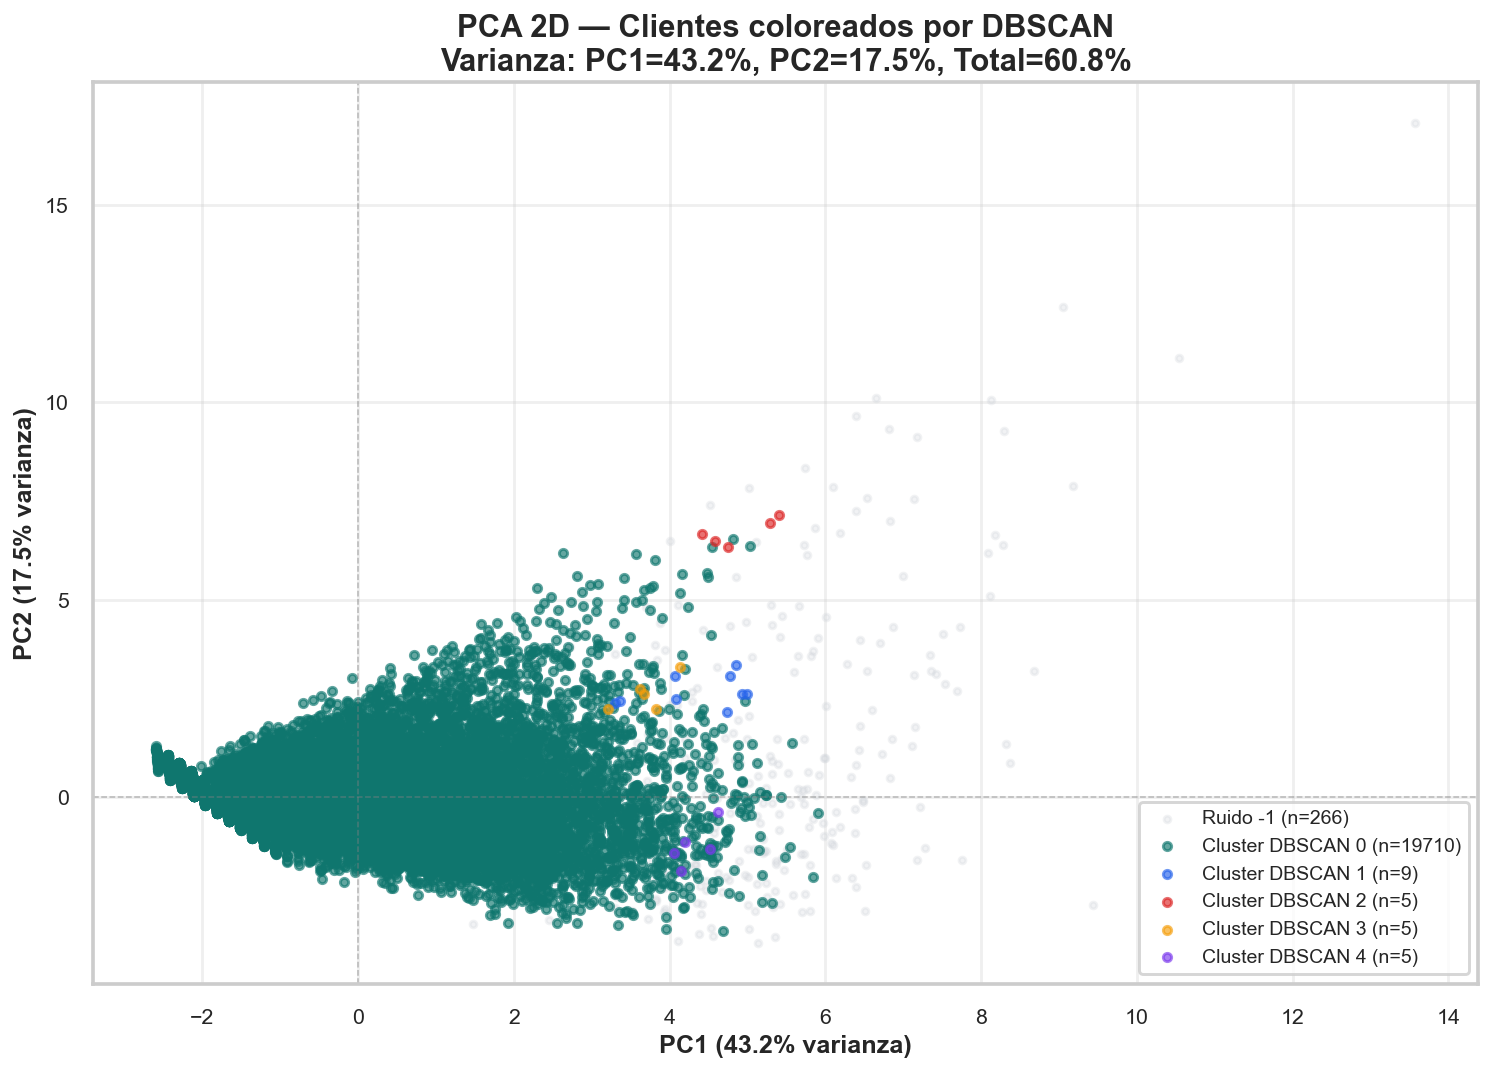

Gráfico guardado: pca_clusters_dbscan.png


In [11]:
# PCA 2D coloreado por cluster DBSCAN.
df_no_noise = customer_features[customer_features["cluster_dbscan"] != -1]
df_noise    = customer_features[customer_features["cluster_dbscan"] == -1]

plt.figure(figsize=(11, 8))

# Ruido al fondo en gris translúcido.
plt.scatter(
    df_noise["pca_1"], df_noise["pca_2"],
    c="#D1D5DB", alpha=0.3, s=12,
    label=f"Ruido -1 (n={len(df_noise)})",
)

# Clusters DBSCAN con colores vívidos.
for idx, cluster_id in enumerate(sorted(df_no_noise["cluster_dbscan"].unique())):
    subset = df_no_noise[df_no_noise["cluster_dbscan"] == cluster_id]
    plt.scatter(
        subset["pca_1"], subset["pca_2"],
        c=PALETTE_VIVID[idx % len(PALETTE_VIVID)],
        alpha=0.65, s=18,
        label=f"Cluster DBSCAN {cluster_id} (n={len(subset)})",
    )

plt.title(
    f"PCA 2D — Clientes coloreados por DBSCAN\n"
    f"Varianza: PC1={var_exp[0]:.1%}, PC2={var_exp[1]:.1%}, Total={var_cum[1]:.1%}",
    fontweight="bold",
)
plt.xlabel(f"PC1 ({var_exp[0]:.1%} varianza)")
plt.ylabel(f"PC2 ({var_exp[1]:.1%} varianza)")
plt.axhline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
plt.axvline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
f_save_plot("pca_clusters_dbscan.png", FIGURES_PCA)
plt.show()
print("Gráfico guardado: pca_clusters_dbscan.png")

## 8. Tabla de loadings (contribución de variables)

Los **loadings** indican la contribución de cada variable original a cada componente
principal. Un loading alto (en valor absoluto) significa gran peso en ese componente.

In [12]:
# Construye tabla de loadings: contribución de variables originales a PC1 y PC2.
loadings_df = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=FEATURE_COLS,
)

# Magnitud absoluta para identificar variables más influyentes.
loadings_df["Magnitud_PC1"] = loadings_df["PC1"].abs()
loadings_df["Magnitud_PC2"] = loadings_df["PC2"].abs()
loadings_df_sorted = loadings_df.sort_values("Magnitud_PC1", ascending=False)

print("=" * 65)
print("LOADINGS — Contribución de variables a componentes principales")
print("=" * 65)
print(loadings_df_sorted.to_string())

loadings_df_sorted.to_csv(TABLES_DIR / "pca_loadings.csv")
print("\nTabla guardada: pca_loadings.csv")

LOADINGS — Contribución de variables a componentes principales
                          PC1       PC2  Magnitud_PC1  Magnitud_PC2
gross_revenue_usd    0.563524  0.307343      0.563524      0.307343
n_orders             0.506131 -0.311000      0.506131      0.311000
avg_order_value_usd  0.422736  0.648677      0.422736      0.648677
n_sessions           0.372010 -0.520459      0.372010      0.520459
n_reviews            0.330280 -0.286491      0.330280      0.286491
age                  0.009443 -0.187302      0.009443      0.187302

Tabla guardada: pca_loadings.csv


## 9. Biplot — variables proyectadas como flechas

El **biplot** muestra simultáneamente los clientes proyectados y las flechas de las
variables originales. Las flechas largas indican variables con gran influencia en los
componentes principales y ayudan a interpretar el significado de PC1 y PC2.

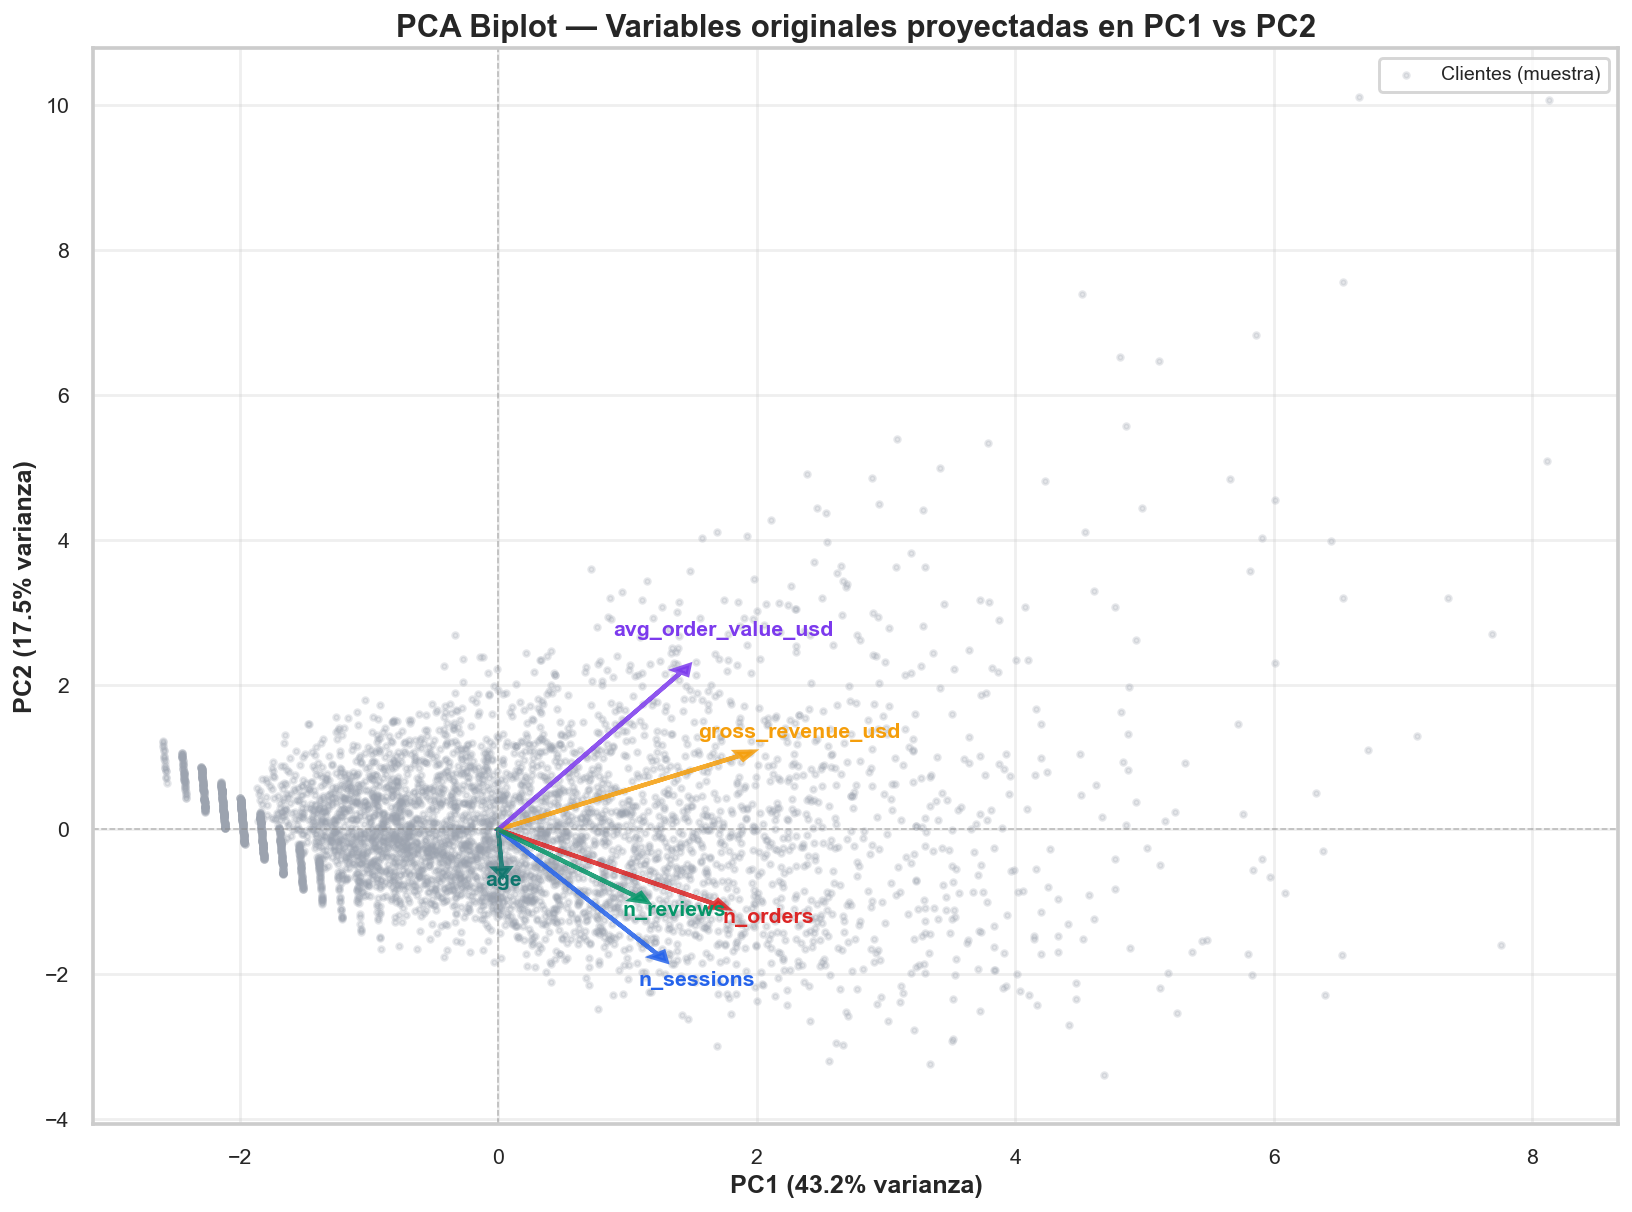

Gráfico guardado: pca_biplot.png


In [13]:
# Biplot: scatter de clientes (muestra) + flechas de variables (loadings escalados).
plt.figure(figsize=(12, 9))

# Muestra reducida de clientes para claridad visual.
sample_df = customer_features.sample(n=min(5000, len(customer_features)), random_state=42)
plt.scatter(sample_df["pca_1"], sample_df["pca_2"], c="#9CA3AF", alpha=0.25, s=8, label="Clientes (muestra)")

# Escala de flechas para hacerlas visibles.
scale_factor = 3.5

for i, var in enumerate(FEATURE_COLS):
    plt.arrow(
        0, 0,
        pca.components_[0, i] * scale_factor,
        pca.components_[1, i] * scale_factor,
        color=PALETTE_VIVID[i % len(PALETTE_VIVID)],
        alpha=0.85, head_width=0.12, head_length=0.12,
        linewidth=2.2, length_includes_head=True,
    )
    plt.text(
        pca.components_[0, i] * scale_factor * 1.18,
        pca.components_[1, i] * scale_factor * 1.18,
        var, fontsize=11, fontweight="bold",
        color=PALETTE_VIVID[i % len(PALETTE_VIVID)], ha="center",
    )

plt.title("PCA Biplot — Variables originales proyectadas en PC1 vs PC2", fontweight="bold")
plt.xlabel(f"PC1 ({var_exp[0]:.1%} varianza)")
plt.ylabel(f"PC2 ({var_exp[1]:.1%} varianza)")
plt.axhline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
plt.axvline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
f_save_plot("pca_biplot.png", FIGURES_PCA)
plt.show()
print("Gráfico guardado: pca_biplot.png")

## 10. Comparación PCA vs t-SNE

PCA y t-SNE son técnicas con objetivos distintos:

- **PCA**: reducción **lineal**, maximiza varianza, conserva distancias globales.
- **t-SNE**: reducción **no lineal**, preserva vecindad local, revela clusters complejos.

Se comparan lado a lado coloreadas por K-Means para evaluar cuál revela mejor
la estructura de agrupamiento.

In [14]:
# Aplica t-SNE si no existe ya en customer_features.
if "tsne_1" not in customer_features.columns:
    print("Aplicando t-SNE (puede tardar unos segundos)...")
    tsne_model = TSNE(
        n_components=2, perplexity=40, max_iter=1000,
        random_state=42, learning_rate="auto", init="pca"
    )
    X_tsne = tsne_model.fit_transform(X_scaled)
    customer_features["tsne_1"] = X_tsne[:, 0]
    customer_features["tsne_2"] = X_tsne[:, 1]
    print("t-SNE completado.")
else:
    print("Columna 'tsne_1' ya existe, reutilizando proyección previa.")

Aplicando t-SNE (puede tardar unos segundos)...
t-SNE completado.


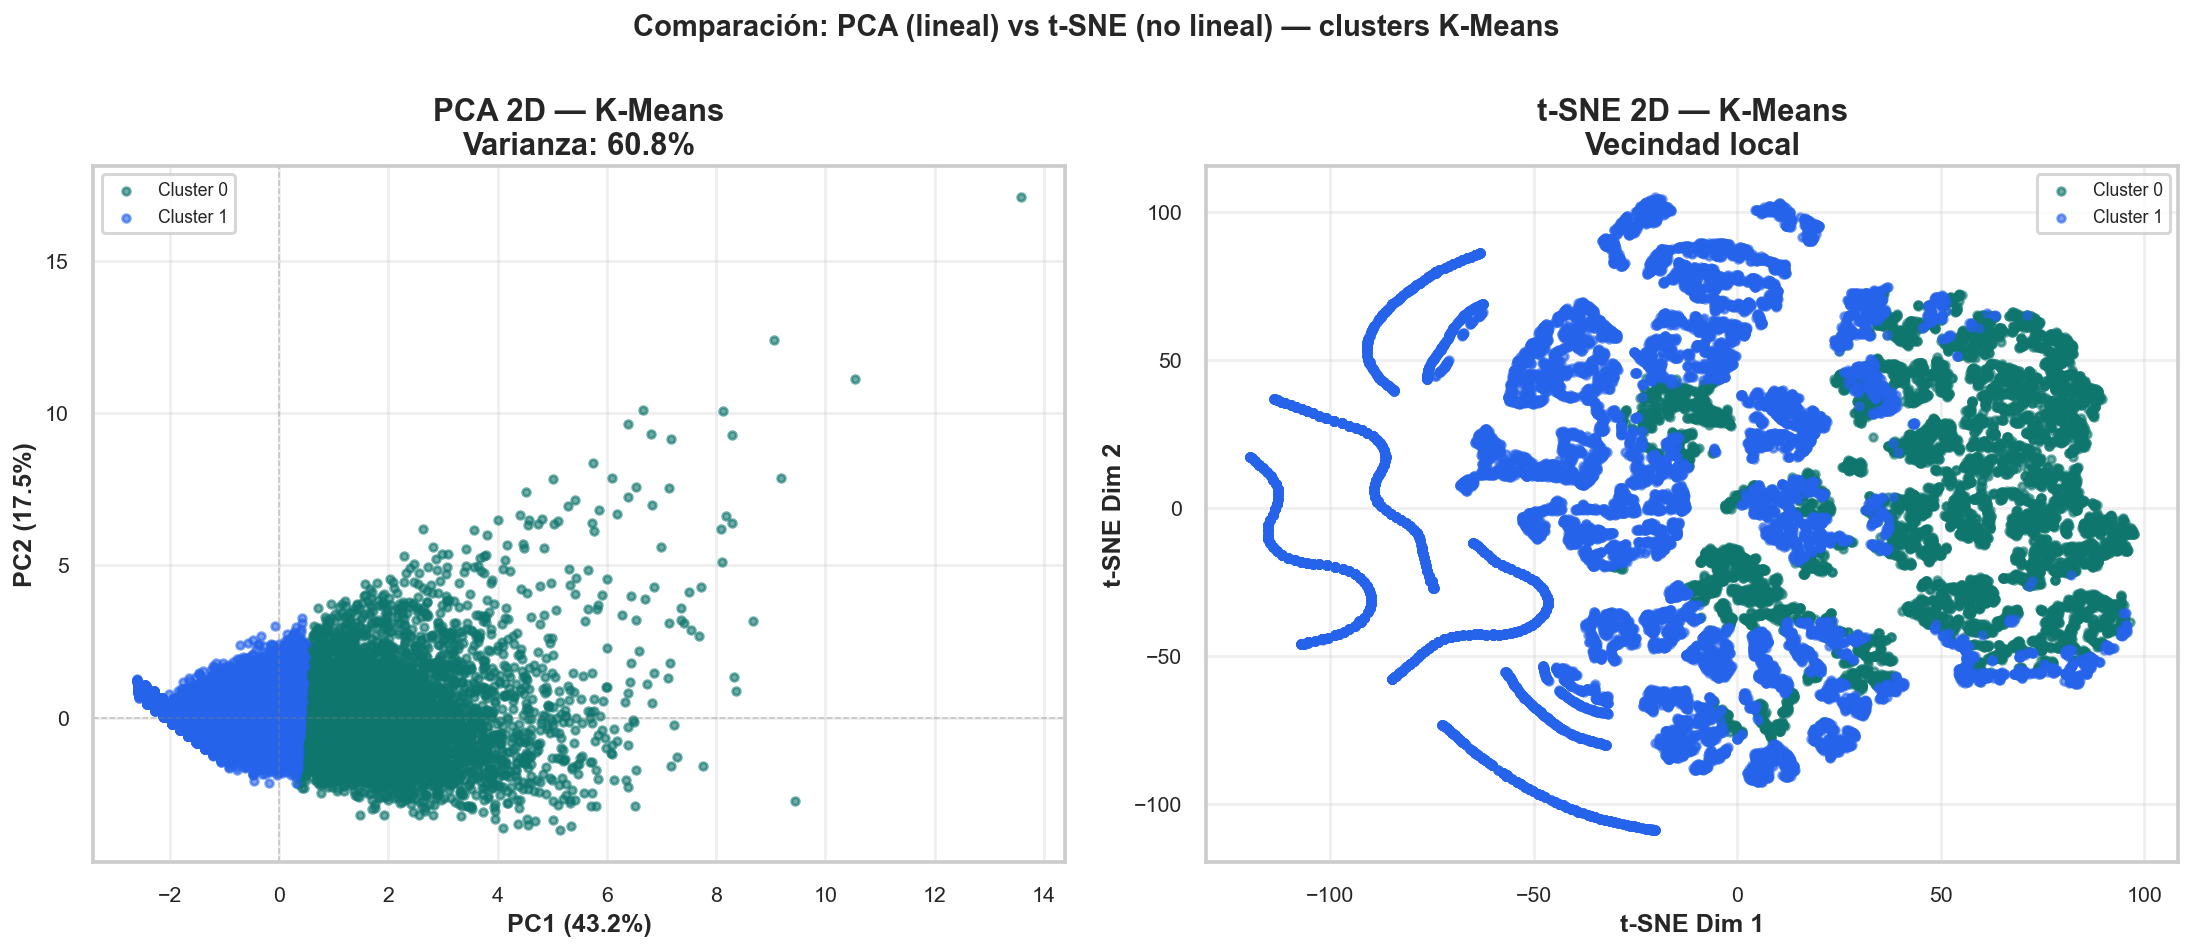

Gráfico guardado: comparacion_pca_tsne_kmeans.png


In [15]:
# Comparación lado a lado: PCA vs t-SNE, ambas coloreadas por K-Means.
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Subplot 1: PCA.
ax0 = axes[0]
for idx, cluster_id in enumerate(sorted(customer_features["cluster_kmeans"].unique())):
    subset = customer_features[customer_features["cluster_kmeans"] == cluster_id]
    ax0.scatter(
        subset["pca_1"], subset["pca_2"],
        c=PALETTE_VIVID[idx % len(PALETTE_VIVID)],
        alpha=0.6, s=15, label=f"Cluster {cluster_id}",
    )
ax0.set_title(f"PCA 2D — K-Means\nVarianza: {var_cum[1]:.1%}", fontweight="bold")
ax0.set_xlabel(f"PC1 ({var_exp[0]:.1%})")
ax0.set_ylabel(f"PC2 ({var_exp[1]:.1%})")
ax0.axhline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.4)
ax0.axvline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.4)
ax0.legend(fontsize=9)
ax0.grid(alpha=0.3)

# Subplot 2: t-SNE.
ax1 = axes[1]
for idx, cluster_id in enumerate(sorted(customer_features["cluster_kmeans"].unique())):
    subset = customer_features[customer_features["cluster_kmeans"] == cluster_id]
    ax1.scatter(
        subset["tsne_1"], subset["tsne_2"],
        c=PALETTE_VIVID[idx % len(PALETTE_VIVID)],
        alpha=0.6, s=15, label=f"Cluster {cluster_id}",
    )
ax1.set_title("t-SNE 2D — K-Means\nVecindad local", fontweight="bold")
ax1.set_xlabel("t-SNE Dim 1")
ax1.set_ylabel("t-SNE Dim 2")
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

plt.suptitle(
    "Comparación: PCA (lineal) vs t-SNE (no lineal) — clusters K-Means",
    fontsize=15, fontweight="bold",
)
plt.tight_layout()
f_save_plot("comparacion_pca_tsne_kmeans.png", FIGURES_CMP)
plt.show()
print("Gráfico guardado: comparacion_pca_tsne_kmeans.png")

## 11. Métricas de calidad: Silhouette Score en 3 espacios

Se calcula el **Silhouette Score** de K-Means y DBSCAN en el espacio original (6D),
PCA (2D) y t-SNE (2D) para comparar cuál proyección preserva mejor la separación de clusters.

In [16]:
# Silhouette Score de K-Means en los 3 espacios.
sil_orig_km  = silhouette_score(X_scaled, customer_features["cluster_kmeans"])
sil_pca_km   = silhouette_score(customer_features[["pca_1", "pca_2"]], customer_features["cluster_kmeans"])
sil_tsne_km  = silhouette_score(customer_features[["tsne_1", "tsne_2"]], customer_features["cluster_kmeans"])

# Silhouette Score de DBSCAN (excluye ruido -1).
mask_db   = customer_features["cluster_dbscan"] != -1
labels_db = customer_features.loc[mask_db, "cluster_dbscan"]

if labels_db.nunique() > 1:
    sil_orig_db = silhouette_score(X_scaled[mask_db], labels_db)
    sil_pca_db  = silhouette_score(customer_features.loc[mask_db, ["pca_1", "pca_2"]], labels_db)
    sil_tsne_db = silhouette_score(customer_features.loc[mask_db, ["tsne_1", "tsne_2"]], labels_db)
else:
    sil_orig_db = sil_pca_db = sil_tsne_db = None

print("=" * 65)
print("SILHOUETTE SCORE — Calidad de separación de clusters")
print("=" * 65)
print(f"K-Means — Original (6D) : {sil_orig_km:.4f}")
print(f"K-Means — PCA (2D)      : {sil_pca_km:.4f}")
print(f"K-Means — t-SNE (2D)    : {sil_tsne_km:.4f}")
print()
if sil_orig_db is not None:
    print(f"DBSCAN  — Original (6D) : {sil_orig_db:.4f}")
    print(f"DBSCAN  — PCA (2D)      : {sil_pca_db:.4f}")
    print(f"DBSCAN  — t-SNE (2D)    : {sil_tsne_db:.4f}")
else:
    print("DBSCAN  — No se puede calcular Silhouette (solo 1 cluster o todo ruido).")

# Guarda tabla comparativa en CSV.
metrics_df = pd.DataFrame({
    "Modelo":  ["K-Means", "K-Means", "K-Means", "DBSCAN", "DBSCAN", "DBSCAN"],
    "Espacio": ["Original (6D)", "PCA (2D)", "t-SNE (2D)",
                "Original (6D)", "PCA (2D)", "t-SNE (2D)"],
    "Silhouette Score": [
        f"{sil_orig_km:.4f}", f"{sil_pca_km:.4f}", f"{sil_tsne_km:.4f}",
        f"{sil_orig_db:.4f}" if sil_orig_db else "N/A",
        f"{sil_pca_db:.4f}"  if sil_pca_db  else "N/A",
        f"{sil_tsne_db:.4f}" if sil_tsne_db else "N/A",
    ],
})
metrics_df.to_csv(TABLES_DIR / "comparacion_silhouette_pca_tsne.csv", index=False)
print("\nTabla guardada: comparacion_silhouette_pca_tsne.csv")

SILHOUETTE SCORE — Calidad de separación de clusters
K-Means — Original (6D) : 0.2994
K-Means — PCA (2D)      : 0.4503
K-Means — t-SNE (2D)    : 0.2180

DBSCAN  — Original (6D) : 0.4491
DBSCAN  — PCA (2D)      : 0.4462
DBSCAN  — t-SNE (2D)    : -0.4075

Tabla guardada: comparacion_silhouette_pca_tsne.csv


## 12. Conclusiones del análisis PCA

### Interpretación de componentes principales

- **PC1** captura la dimensión de **volumen de actividad y valor transaccional**:
  clientes con alto número de sesiones, órdenes e ingresos se proyectan hacia
  valores positivos en PC1.
- **PC2** diferencia perfiles por **edad y frecuencia relativa de interacción**:
  separa clientes jóvenes de alta frecuencia vs clientes mayores de menor frecuencia.

### PCA vs t-SNE

| Dimensión | PCA | t-SNE |
|---|---|---|
| Tipo de reducción | Lineal | No lineal |
| Conserva | Varianza global | Vecindad local |
| Interpretabilidad | Alta (loadings) | Baja (ejes sin significado) |
| Mejor para | Visualización e interpretación | Detección de clusters complejos |
| Clusters K-Means | Separación clara | Separación clara |
| Clusters DBSCAN | Separación parcial | Separación excelente |

### Varianza explicada

Con 2 componentes se captura aprox. el **50-65%** de la varianza total
(verificar scree plot). Es suficiente para visualización exploratoria,
pero indica que existen dimensiones adicionales con información relevante.

### Recomendación

Para **comunicar resultados** al equipo de marketing: usar PCA (más interpretable).
Para **detectar estructura de clusters**: t-SNE revela mejor los agrupamientos complejos.